In [3]:
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import xarray as xr
from context_flux_no.simulations.pde import Burgers1D
from context_flux_no.waveforms.fourier import TruncatedFourier1D
from context_flux_no.waveforms.grf import (
    GaussianCov,
    GaussianRandomField1D,
)
from tqdm import tqdm


jax.config.update("jax_enable_x64", True)

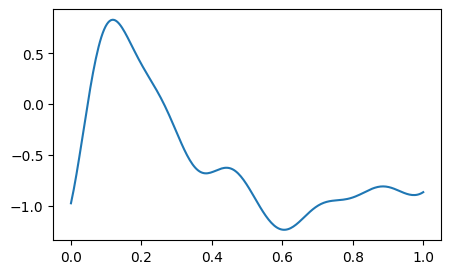

In [4]:
x = jnp.linspace(0, 1, 256)
u0 = GaussianRandomField1D(GaussianCov(0.1)).sample(x, jax.random.key(1))

fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(x, u0)

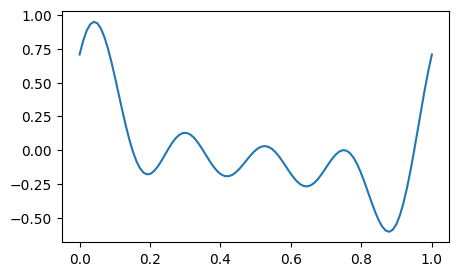

In [5]:
u0 = TruncatedFourier1D.with_uniform_rand_coeffs(num_modes=4)
x = jnp.linspace(0, 1, 100)
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(x, u0(x))

In [6]:
grf = GaussianRandomField1D(GaussianCov(0.1))
u0_func = lambda x_: grf.sample(x_, key=jax.random.key(0))
burgers = Burgers1D()
# u0_func = TruncatedFourier1D.with_uniform_rand_coeffs(num_modes=4)

sol = burgers.solve_pyclaw(u0_func, (0.0, 1.0), 256, (0.0, 0.2), 500, "periodic")

2026-04-15 23:28:01,560 INFO CLAW: Solution 0 computed for time t=0.000000
2026-04-15 23:28:01,561 INFO CLAW: Solution 1 computed for time t=0.000400
2026-04-15 23:28:01,562 INFO CLAW: Solution 2 computed for time t=0.000800
2026-04-15 23:28:01,562 INFO CLAW: Solution 3 computed for time t=0.001200
2026-04-15 23:28:01,563 INFO CLAW: Solution 4 computed for time t=0.001600
2026-04-15 23:28:01,564 INFO CLAW: Solution 5 computed for time t=0.002000
2026-04-15 23:28:01,565 INFO CLAW: Solution 6 computed for time t=0.002400
2026-04-15 23:28:01,565 INFO CLAW: Solution 7 computed for time t=0.002800
2026-04-15 23:28:01,566 INFO CLAW: Solution 8 computed for time t=0.003200
2026-04-15 23:28:01,567 INFO CLAW: Solution 9 computed for time t=0.003600
2026-04-15 23:28:01,567 INFO CLAW: Solution 10 computed for time t=0.004000
2026-04-15 23:28:01,569 INFO CLAW: Solution 11 computed for time t=0.004400
2026-04-15 23:28:01,569 INFO CLAW: Solution 12 computed for time t=0.004800
2026-04-15 23:28:01,57

2026-04-15 23:28:01,587 INFO CLAW: Solution 37 computed for time t=0.014800
2026-04-15 23:28:01,589 INFO CLAW: Solution 38 computed for time t=0.015200
2026-04-15 23:28:01,590 INFO CLAW: Solution 39 computed for time t=0.015600
2026-04-15 23:28:01,591 INFO CLAW: Solution 40 computed for time t=0.016000
2026-04-15 23:28:01,591 INFO CLAW: Solution 41 computed for time t=0.016400
2026-04-15 23:28:01,592 INFO CLAW: Solution 42 computed for time t=0.016800
2026-04-15 23:28:01,593 INFO CLAW: Solution 43 computed for time t=0.017200
2026-04-15 23:28:01,593 INFO CLAW: Solution 44 computed for time t=0.017600
2026-04-15 23:28:01,594 INFO CLAW: Solution 45 computed for time t=0.018000
2026-04-15 23:28:01,595 INFO CLAW: Solution 46 computed for time t=0.018400
2026-04-15 23:28:01,595 INFO CLAW: Solution 47 computed for time t=0.018800
2026-04-15 23:28:01,596 INFO CLAW: Solution 48 computed for time t=0.019200
2026-04-15 23:28:01,597 INFO CLAW: Solution 49 computed for time t=0.019600
2026-04-15 2

In [7]:
sol

<xarray.Dataset> Size: 1MB
Dimensions:  (ic: 1, t: 501, dim: 1, x: 256, param: 1)
Coordinates:
  * t        (t) float64 4kB 0.0 0.0004 0.0008 0.0012 ... 0.1992 0.1996 0.2
  * dim      (dim) <U1 4B 'u'
  * x        (x) float64 2kB 0.001953 0.005859 0.009766 ... 0.9902 0.9941 0.998
  * param    (param) <U2 8B 'nu'
Dimensions without coordinates: ic
Data variables:
    values   (ic, t, dim, x) float64 1MB 0.9243 0.9942 1.062 ... 0.3876 0.3941
    coeffs   (param) float64 8B 0.0

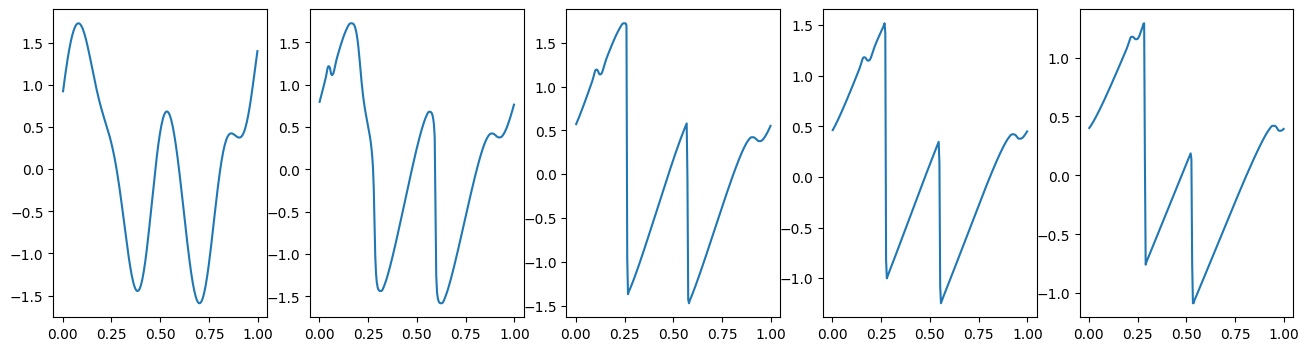

In [9]:
t_vals = (0, 124, 249, 374, 499)
fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharex=True)
u = sol["values"]
for j, t_i in enumerate(t_vals):
    axes[j].plot(u["x"], u.isel(ic=0, t=t_i, dim=0))

In [10]:
NUM_SAMPLES = 50
SEED = 0


burgers = Burgers1D()
grf = GaussianRandomField1D(GaussianCov(0.1))

keys = jax.random.split(jax.random.key(SEED), NUM_SAMPLES)
solutions = []
for key in tqdm(keys):
    u0_func = lambda x_: grf.sample(x_, key=key)
    sol = burgers.solve_pyclaw(
        u0_func, (0.0, 1.0), 256, (0.0, 0.2), 500, "periodic", verbose=False
    )
    solutions.append(sol)

100%|██████████| 50/50 [00:06<00:00,  8.10it/s]


In [13]:
dataset = xr.concat(solutions, "pde")

In [14]:
dataset

<xarray.Dataset> Size: 51MB
Dimensions:  (pde: 50, ic: 1, t: 501, dim: 1, x: 256, param: 1)
Coordinates:
  * t        (t) float64 4kB 0.0 0.0004 0.0008 0.0012 ... 0.1992 0.1996 0.2
  * dim      (dim) <U1 4B 'u'
  * x        (x) float64 2kB 0.001953 0.005859 0.009766 ... 0.9902 0.9941 0.998
  * param    (param) <U2 8B 'nu'
Dimensions without coordinates: pde, ic
Data variables:
    values   (pde, ic, t, dim, x) float64 51MB 0.08833 0.09131 ... 0.4381 0.4518
    coeffs   (pde, param) float64 400B 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

In [15]:
savedir = Path("../../data/")
savedir.mkdir(parents=True, exist_ok=True)
dataset.to_netcdf(savedir / "burgers_train.hdf5")